In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os
print(os.listdir('/content/drive/My Drive/Group 10 Project/data/eegmmidb/')[:5])

DATA_PATH = "/content/drive/My Drive/Group 10 Project/data/eegmmidb/"

Mounted at /content/drive
['64_channel_sharbrough-old.png', 'SHA256SUMS.txt', 'ANNOTATORS', 'RECORDS', '64_channel_sharbrough.pdf']


saved subject files were created with different epoch lengths. For PCA, everything must have the same feature dimensions, so we need to standardize at load time.

scan all saved subject files

find the most common shape for each condition

keep only arrays matching that shape

skip the mismatches and log them

# **important note**

there exists 3 subjects with incorrect epoching. We have removed these 3 subject in subsequent analysis. (I believe that their epoch lengths were messed up do to a previous run I had initiated erroneously)

loading cell

In [2]:
# ---------------------------------------------------------
# Load processed epoch dataset for PCA analysis
# Excludes subjects with incorrect epoch length
# ---------------------------------------------------------

from pathlib import Path
from collections import defaultdict
import numpy as np
import pandas as pd

base_dir = Path("/content/drive/My Drive/Group 10 Project/data/processed_subject_epochs")

subject_dirs = sorted([
    d for d in base_dir.iterdir()
    if d.is_dir() and d.name.startswith("S")
])

print("Subjects detected:", len(subject_dirs))

# Subjects with incorrect epoch length
bad_subjects = {"S088", "S092", "S100"}

condition_data = defaultdict(list)
metadata_all = []

kept_subjects = []
skipped_subjects = []

for subj_dir in subject_dirs:

    if subj_dir.name in bad_subjects:
        skipped_subjects.append(subj_dir.name)
        continue

    npz_path = subj_dir / "epochs.npz"
    metadata_path = subj_dir / "metadata.csv"

    if not npz_path.exists():
        continue

    subj_npz = np.load(npz_path)

    for cond in subj_npz.files:
        condition_data[cond].append(subj_npz[cond])

    if metadata_path.exists():
        metadata_all.append(pd.read_csv(metadata_path))

    kept_subjects.append(subj_dir.name)

print("Subjects kept:", len(kept_subjects))
print("Subjects excluded:", skipped_subjects)

# ---------------------------------------------------------
# Concatenate safely
# ---------------------------------------------------------

condition_arrays = {}

for cond, arrays in condition_data.items():
    condition_arrays[cond] = np.concatenate(arrays, axis=0)

print("\nCondition dataset shapes:")

for cond in sorted(condition_arrays.keys()):
    print(cond, condition_arrays[cond].shape)

# Combine metadata
metadata_all = pd.concat(metadata_all, ignore_index=True)

print("\nMetadata rows:", len(metadata_all))

Subjects detected: 109
Subjects kept: 106
Subjects excluded: ['S088', 'S092', 'S100']

Condition dataset shapes:
both_feet (4778, 64, 401)
both_fists (4751, 64, 401)
left_fist (4801, 64, 401)
rest (17803, 64, 401)
right_fist (4744, 64, 401)

Metadata rows: 36877


Running PCA just on the left fist to find the best K

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

#PCA ONLY on left fist
X_temp   = condition_arrays["left_fist"].mean(axis=2)
X_scaled = StandardScaler().fit_transform(X_temp)
pca_temp = PCA().fit(X_scaled)

cumvar = np.cumsum(pca_temp.explained_variance_ratio_) * 100
k_80   = np.argmax(cumvar >= 80) + 1
k_90   = np.argmax(cumvar >= 90) + 1
k_95   = np.argmax(cumvar >= 95) + 1

print(f"k for 80% variance: {k_80}")
print(f"k for 90% variance: {k_90}")
print(f"k for 95% variance: {k_95}")

k for 80% variance: 3
k for 90% variance: 11
k for 95% variance: 27


In [4]:
#same but for the right fist
X_temp   = condition_arrays["right_fist"].mean(axis=2)
X_scaled = StandardScaler().fit_transform(X_temp)
pca_temp = PCA().fit(X_scaled)

cumvar = np.cumsum(pca_temp.explained_variance_ratio_) * 100
k_80   = np.argmax(cumvar >= 80) + 1
k_90   = np.argmax(cumvar >= 90) + 1
k_95   = np.argmax(cumvar >= 95) + 1

print(f"k for 80% variance: {k_80}")
print(f"k for 90% variance: {k_90}")
print(f"k for 95% variance: {k_95}")

k for 80% variance: 3
k for 90% variance: 11
k for 95% variance: 27


k = 27 captures 95% of the variance, so will be using k = 27 for further analysis

In [5]:
K = 5

Running PCA on all 5 conditions, using K = 27
IMPORTANT: using time-averaging to reduce the memory usage

In [6]:
from itertools import combinations
from scipy.linalg import subspace_angles
import matplotlib.pyplot as plt

CONDITIONS = ["left_fist", "right_fist", "both_fists", "both_feet", "rest"]

pca_models = {}

for cond in CONDITIONS:
    # Using the mean of the time
    X        = condition_arrays[cond].mean(axis=2)
    X_scaled = StandardScaler().fit_transform(X)
    pca_models[cond] = PCA(n_components=K).fit(X_scaled)
    print(f"PCA fitted: {cond}  shape={X.shape}")

PCA fitted: left_fist  shape=(4801, 64)
PCA fitted: right_fist  shape=(4744, 64)
PCA fitted: both_fists  shape=(4751, 64)
PCA fitted: both_feet  shape=(4778, 64)
PCA fitted: rest  shape=(17803, 64)


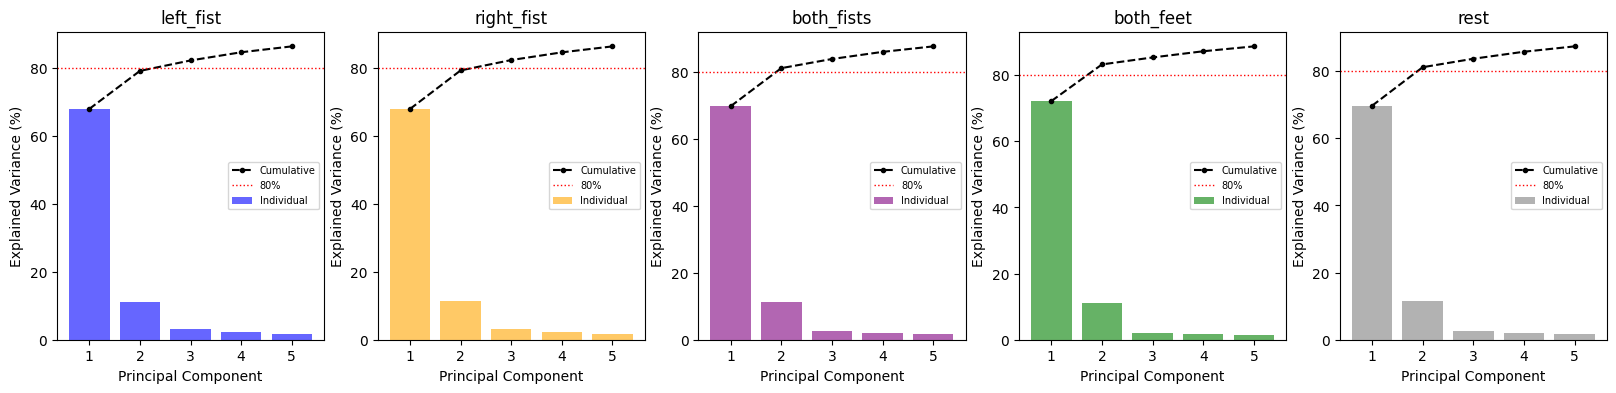

In [7]:
#Scree plot for each condition
colors = ["blue", "orange", "purple", "green", "gray"]
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, cond, color in zip(axes, CONDITIONS, colors):
    ev     = pca_models[cond].explained_variance_ratio_ * 100
    cumvar = np.cumsum(ev)
    comps  = np.arange(1, len(ev) + 1)

    ax.bar(comps, ev, color=color, alpha=0.6, label="Individual")
    ax.plot(comps, cumvar, "k--o", ms=3, label="Cumulative")
    ax.axhline(80, color="red", linestyle=":", linewidth=1, label="80%")
    ax.set_title(cond)
    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance (%)")
    ax.legend(fontsize=7)

plt.show()

Subspace angle analysis

left_fist vs right_fist: 4.6°
left_fist vs both_fists: 6.1°
left_fist vs both_feet: 6.3°
left_fist vs rest: 5.5°
right_fist vs both_fists: 5.9°
right_fist vs both_feet: 5.9°
right_fist vs rest: 4.7°
both_fists vs both_feet: 6.6°
both_fists vs rest: 5.3°
both_feet vs rest: 5.5°


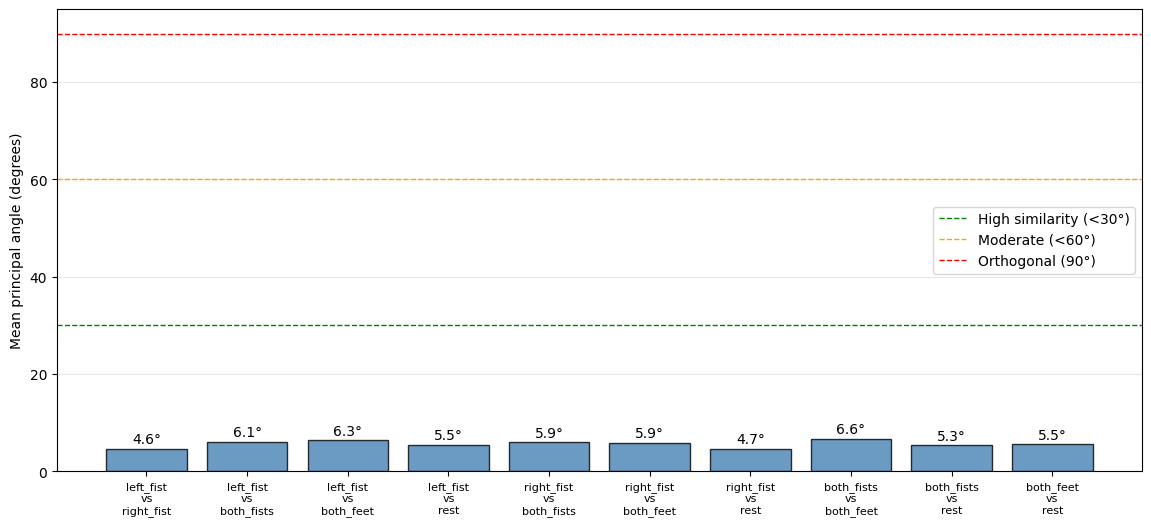

In [8]:
pair_labels = []
mean_angles = []

for cond_a, cond_b in combinations(CONDITIONS, 2):
    U_a = pca_models[cond_a].components_[:K].T
    U_b = pca_models[cond_b].components_[:K].T
    ang = np.degrees(subspace_angles(U_a, U_b)).mean()

    pair_labels.append(f"{cond_a}\nvs\n{cond_b}")
    mean_angles.append(ang)
    print(f"{cond_a} vs {cond_b}: {ang:.1f}°")

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(np.arange(len(pair_labels)), mean_angles,
              color="steelblue", alpha=0.8, edgecolor="black")
ax.set_xticks(np.arange(len(pair_labels)))
ax.set_xticklabels(pair_labels, fontsize=8)
ax.set_ylabel("Mean principal angle (degrees)")
ax.axhline(30, color="green",  linestyle="--", linewidth=1, label="High similarity (<30°)")
ax.axhline(60, color="orange", linestyle="--", linewidth=1, label="Moderate (<60°)")
ax.axhline(90, color="red",    linestyle="--", linewidth=1, label="Orthogonal (90°)")
ax.set_ylim(0, 95)
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, val in zip(bars, mean_angles):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f"{val:.1f}°", ha="center", va="bottom")
plt.show()

Small angle's values show high similarity between subspaces

Checking if the results would significantly change if we would use any other reduction of the time.
1. Time average
2. Time variance
3. Average and variance together

Performing the check only on left VS right and left VS rest

In [9]:
left_epochs  = condition_arrays["left_fist"]
right_epochs = condition_arrays["right_fist"]
rest_epochs  = condition_arrays["rest"]

# Time average that has been used for the prior analysis
X_left_mean  = left_epochs.mean(axis=2)
X_right_mean = right_epochs.mean(axis=2)
X_rest_mean  = rest_epochs.mean(axis=2)

# Time variance shows how much each channel fluctuates
X_left_var  = left_epochs.var(axis=2)
X_right_var = right_epochs.var(axis=2)
X_rest_var  = rest_epochs.var(axis=2)

# Average and variance together
X_left_both  = np.concatenate([X_left_mean,  X_left_var],  axis=1)
X_right_both = np.concatenate([X_right_mean, X_right_var], axis=1)
X_rest_both  = np.concatenate([X_rest_mean,  X_rest_var],  axis=1)

print("Feature shapes:")
print("Mean only:      ", X_left_mean.shape)
print("Var only:       ", X_left_var.shape)
print("Mean + Var:     ", X_left_both.shape)

Feature shapes:
Mean only:       (4801, 64)
Var only:        (4801, 64)
Mean + Var:      (4801, 128)


Running PCA with subspace angles analysis on 3 different approaches

In [10]:
results = {}

# Scale
def scale(X):
    return StandardScaler().fit_transform(X)


for name, Xl, Xr, Xrs in [
    ("Time-mean",     X_left_mean,  X_right_mean,  X_rest_mean),
    ("Time-variance", X_left_var,   X_right_var,   X_rest_var),
    ("Mean+Var",      X_left_both,  X_right_both,  X_rest_both),
]:

    Xl_s  = scale(Xl)
    Xr_s  = scale(Xr)
    Xrs_s = scale(Xrs)

    # PCA
    pca_l  = PCA(n_components=K).fit(Xl_s)
    pca_r  = PCA(n_components=K).fit(Xr_s)
    pca_rs = PCA(n_components=K).fit(Xrs_s)

    # Subspace angles
    ang_lr   = np.degrees(subspace_angles(
        pca_l.components_[:K].T, pca_r.components_[:K].T)).mean()
    ang_lrst = np.degrees(subspace_angles(
        pca_l.components_[:K].T, pca_rs.components_[:K].T)).mean()

    results[name] = {"Left vs Right": ang_lr, "Left vs Rest": ang_lrst}
    print(f"\n{name}")
    print(f"  Left vs Right : {ang_lr:.2f}°")
    print(f"  Left vs Rest  : {ang_lrst:.2f}°")


Time-mean
  Left vs Right : 4.60°
  Left vs Rest  : 5.45°

Time-variance
  Left vs Right : 20.15°
  Left vs Rest  : 22.35°

Mean+Var
  Left vs Right : 5.14°
  Left vs Rest  : 7.53°


Small angle's values still show high similarity for all approaches

Saving time-averaging for comparison with flattened epoch

In [11]:
np.savez(
    "/content/drive/My Drive/pca_timeavg_components.npz",
    **{cond: pca_models[cond].components_ for cond in CONDITIONS}
)
print("Time-averaged components saved!")

Time-averaged components saved!
